In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


In [5]:
df = pd.read_csv("data/superstore_cleaned.csv")
df

,row_id+o6g3a1:r6,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub-category,product_name,sales,quantity,profit,returns,payment_mode
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.940,1,28.2668,No,Online
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.940,3,38.2668,No,Online
2,4920,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,East,TEC-PH-10000455,Technology,Phones,GE 30522EE2,231.980,2,67.2742,No,Cards
3,3074,CA-2019-125206,2019-01-03,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,West,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.460,2,28.6150,No,Online
4,8604,US-2019-116365,2019-01-03,2019-01-08,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,Central,TEC-AC-10002217,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.080,2,-5.2640,No,Online
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5896,907,CA-2020-143259,2020-12-30,2021-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,East,FUR-BO-10003441,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Fully Ass...",213.136,4,12.1176,No,COD
5897,1297,CA-2020-115427,2020-12-30,2021-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",295.904,2,4.5188,1.0,Online
5898,5092,CA-2020-156720,2020-12-30,2021-01-03,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,388.024,3,-0.6048,No,Online
5899,909,CA-2020-143259,2020-12-30,2021-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,462.776,3,19.7910,No,COD


In [7]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])


In [9]:
# Overall Business Overview

total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()

total_sales, total_profit, total_orders


(np.float64(1565804.3232), np.float64(175262.1059), 3003)

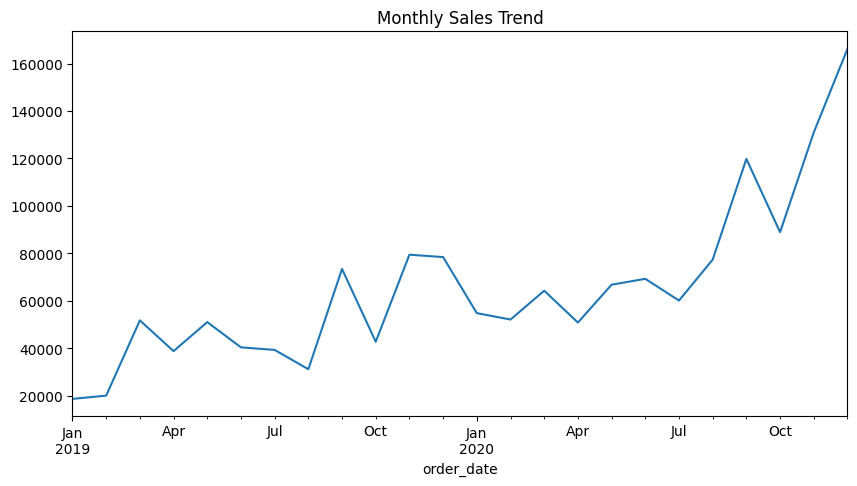

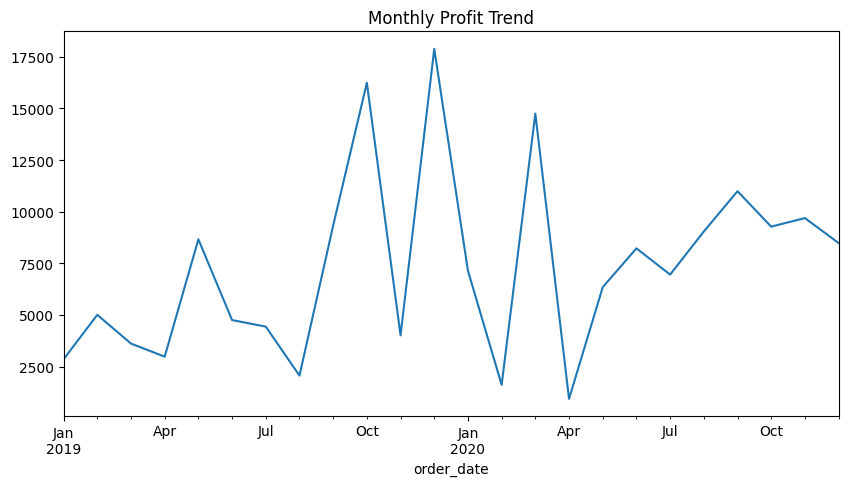

In [11]:
# Sales & Profit Trend Over Time

monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()
monthly_profit = df.groupby(df['order_date'].dt.to_period('M'))['profit'].sum()

monthly_sales.plot(figsize=(10,5), title="Monthly Sales Trend")
plt.show()

monthly_profit.plot(figsize=(10,5), title="Monthly Profit Trend")
plt.show()


                       sales      profit
category                                
Furniture        451508.6452  10006.6112
Office Supplies  643707.6870  74797.2461
Technology       470587.9910  90458.2486


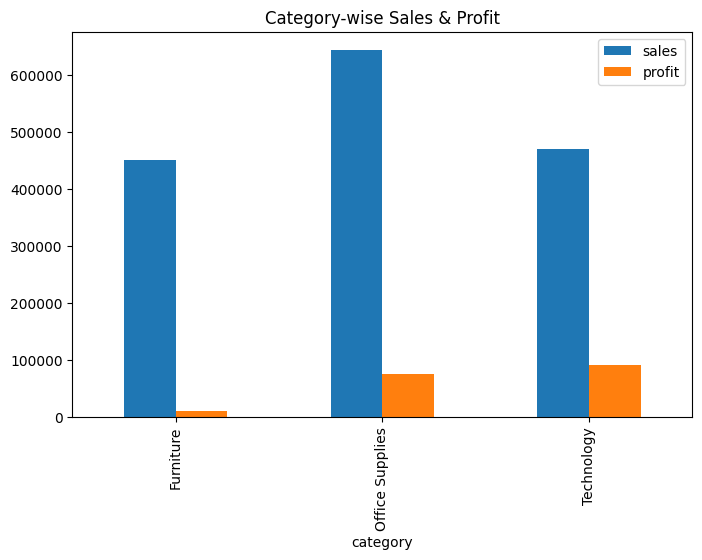

In [14]:
category_analysis = df.groupby('category')[['sales','profit']].sum()
print(category_analysis)
category_analysis.plot(kind='bar', figsize=(8,5), title="Category-wise Sales & Profit")
plt.show()


sub-category
Phones         196563.546
Chairs         181945.998
Binders        174978.390
Storage        150341.318
Accessories    122301.086
Tables         119293.743
Paper           99453.612
Furnishings     92691.218
Machines        91987.561
Appliances      80305.247
Name: sales, dtype: float64


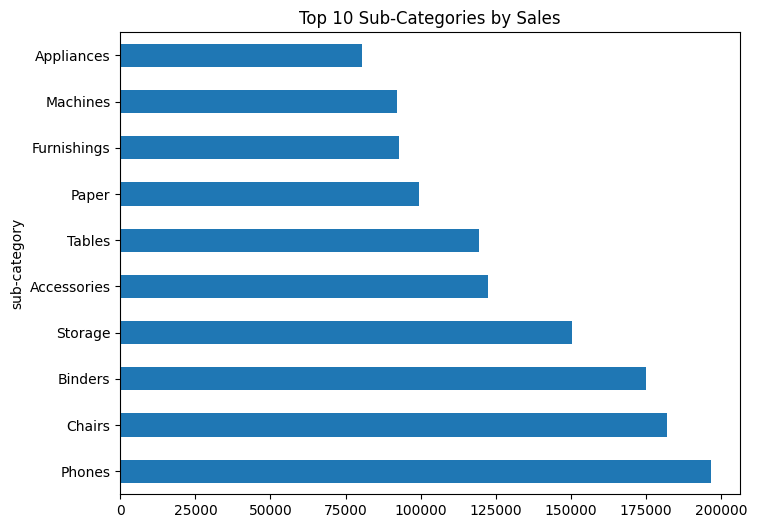

In [16]:
sub_category_sales = (
    df.groupby('sub-category')['sales']
    .sum()
    .sort_values(ascending=False)
)

print(sub_category_sales.head(10))


sub_category_sales.head(10).plot(kind='barh', figsize=(8,6), title="Top 10 Sub-Categories by Sales")
plt.show()


               sales      profit
region                          
Central  341007.5242  27450.0071
East     450234.6660  53400.4243
South    252121.0810  26551.7163
West     522441.0520  67859.9582


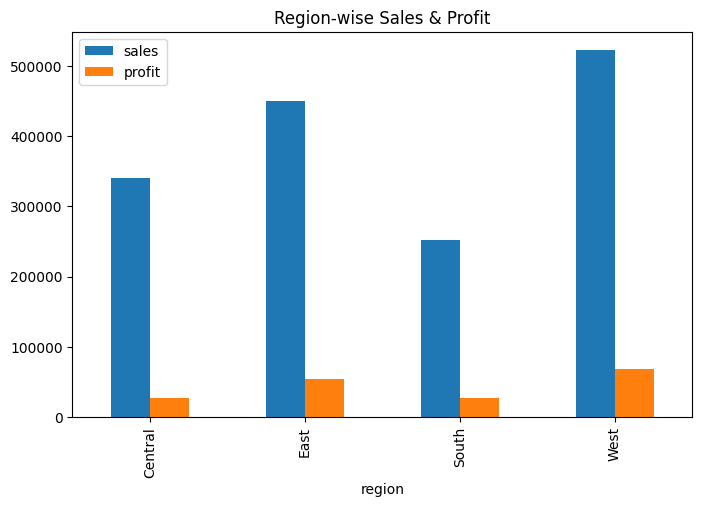

In [18]:
region_analysis = df.groupby('region')[['sales','profit']].sum()
print(region_analysis)


region_analysis.plot(kind='bar', figsize=(8,5), title="Region-wise Sales & Profit")
plt.show()


In [20]:
loss_products = df[df['profit'] < 0].sort_values('profit')
loss_products[['product_name','category','sales','profit']].head(10)


,product_name,category,sales,profit
2184,Cubify CubeX 3D Printer Double Head Print,Technology,4499.985,-6599.9780
5037,Cubify CubeX 3D Printer Triple Head Print,Technology,3009.980,-3839.9904
3193,Lexmark MX611dhe Monochrome Laser Printer,Technology,2579.985,-3399.9800
5569,Ibico EPK-21 Electric Binding System,Office Supplies,1901.990,-2929.4845
5276,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,1556.188,-2287.7820
383,GBC DocuBind P400 Electric Binding System,Office Supplies,1088.792,-1850.9464
4845,GBC DocuBind P400 Electric Binding System,Office Supplies,1677.188,-1306.5504
4075,GBC DocuBind TL300 Electric Binding System,Office Supplies,1641.582,-1237.8462
4384,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,804.594,-1143.8910
2618,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,790.980,-1141.4700


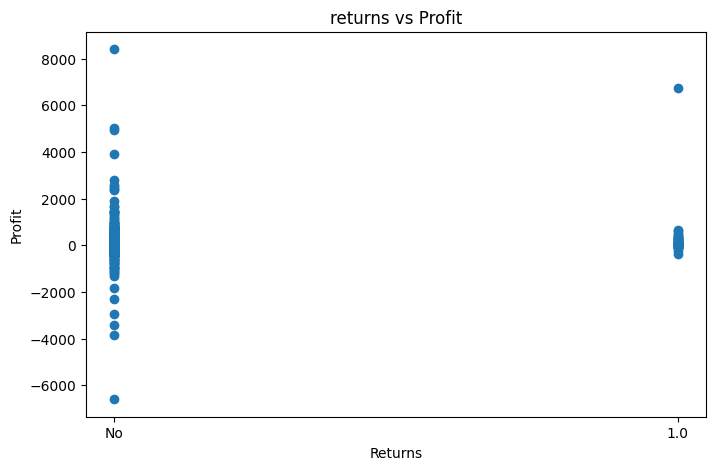

In [24]:
plt.figure(figsize=(8,5))
plt.scatter(df['returns'], df['profit'])
plt.title("returns vs Profit")
plt.xlabel("Returns")
plt.ylabel("Profit")
plt.show()


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   row_id+o6g3a1:r6  5901 non-null   int64         
 1   order_id          5901 non-null   object        
 2   order_date        5901 non-null   datetime64[ns]
 3   ship_date         5901 non-null   datetime64[ns]
 4   ship_mode         5901 non-null   object        
 5   customer_id       5901 non-null   object        
 6   customer_name     5901 non-null   object        
 7   segment           5901 non-null   object        
 8   country           5901 non-null   object        
 9   city              5901 non-null   object        
 10  state             5901 non-null   object        
 11  region            5901 non-null   object        
 12  product_id        5901 non-null   object        
 13  category          5901 non-null   object        
 14  sub-category      5901 n